<a href="https://colab.research.google.com/github/Roshni-AngelAlex/DEEP-LEARNING/blob/main/24BAD101_(_DEEP_LEARNING_LAB_EX_1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**DEEP LEARNING (24ADI006)**

**BUILDING AND TRAINING A SIMPLE ARTIFICIAL NEURAL NETWORK (ANN) FOR REGRESSION AND CLASSIFICATION**

**LAB EXCERCISE 1**

NAME : ROSHNI ANGEL A

ROLL NO :24BAD101

Task A – ANN FOR REGRESSION

DATASET: California Housing Dataset

SOURCE: Scikit-learn

DESCRIPTION

•	Samples: 20,640

•	Features: 8

•	Target: Median House Value



First Five Rows
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  

Dataset Shape
(20640, 10)
Training data shape (before pre

/tmp/ipykernel_714/1805484915.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 56012288000.0000 - mae: 206699.0625 - val_loss: 56273440768.0000 - val_mae: 206593.7188
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 53916557312.0000 - mae: 202045.7500 - val_loss: 52132876288.0000 - val_mae: 197340.1406
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 47459577856.0000 - mae: 186912.9844 - val_loss: 43233918976.0000 - val_mae: 175792.8906
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 36947845120.0000 - mae: 159480.7812 - val_loss: 31440748544.0000 - val_mae: 143223.8125
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 25395386368.0000 - mae: 124818.3984 - val_loss: 20593184768.0000 - val_mae: 108795.6328
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 16434999296.0000 - mae: 95048.3359 - val_loss: 13656206336.0000 - val_mae: 84539.0703
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 11480272896.0000 - mae: 77939.8750 - val_loss: 1040039

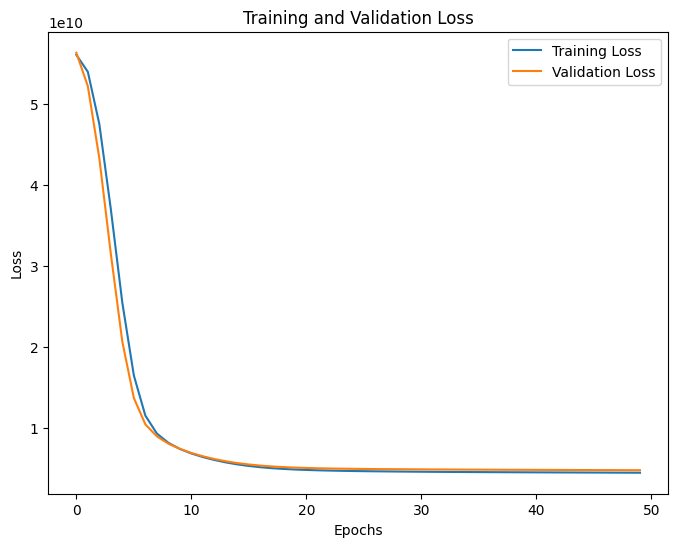

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from google.colab import files

# Assuming the file 'housing.csv' has been uploaded
# uploaded = files.upload() # This line will cause a prompt in Colab, remove if file is already there

df = pd.read_csv("housing.csv")

print("\nFirst Five Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

# Handle missing values in 'total_bedrooms' by filling with the median
df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)

X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(exclude=['object']).columns

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data shape (before preprocessing):", X_train.shape)
print("Testing data shape (before preprocessing):", X_test.shape)

# Apply preprocessing
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

print("Training data shape (after preprocessing):", X_train.shape)
print("Testing data shape (after preprocessing):", X_test.shape)

model = Sequential()

# The input_shape should match the number of features after one-hot encoding and scaling
# If X_train is a numpy array, X_train.shape[1] gives the number of features
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.summary()

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\nRESULTS")
print("Mean Squared Error =", mse)
print("Mean Absolute Error =", mae)
print("Root Mean Squared Error =", rmse)

plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()

Task B – ANN FOR CLASSIFICATION

DATASET: Breast Cancer Wisconsin Dataset

SOURCE: Scikit-learn

DESCRIPTION

•	Samples: 569

•	Features: 30

•	Classes:

o	Malignant

o	Benign


In [ ]:
!pip install tensorflow

EXPT NO : 1
ARTIFICIAL NEURAL NETWORK FOR CLASSIFICATION
NAME    : ROSHNI ANGEL A
ROLL NO : 24BAD101


Saving data.csv to data (1).csv
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6923 - loss: 0.6133 - val_accuracy: 0.9121 - val_loss: 0.4176
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9313 - loss: 0.3322 - val_accuracy: 0.9670 - val_loss: 0.2674
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9505 - loss: 0.2156 - val_accuracy: 0.9670 - val_loss: 0.1911
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9615 - loss: 0.1577 - val_accuracy: 0.9670 - val_loss: 0.1537
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9698 - loss: 0.1255 - val_accuracy: 0.9670 - val_loss: 0.1346
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9753 - loss: 0.1068 - val_accuracy: 0.9670 - val_loss: 0.1211
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9753 - loss: 0.0934 - val_accuracy: 0.9670 - val_loss: 0.1117
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9725 - loss: 0.0831 - val_accuracy: 0.9670 - val_loss: 0.

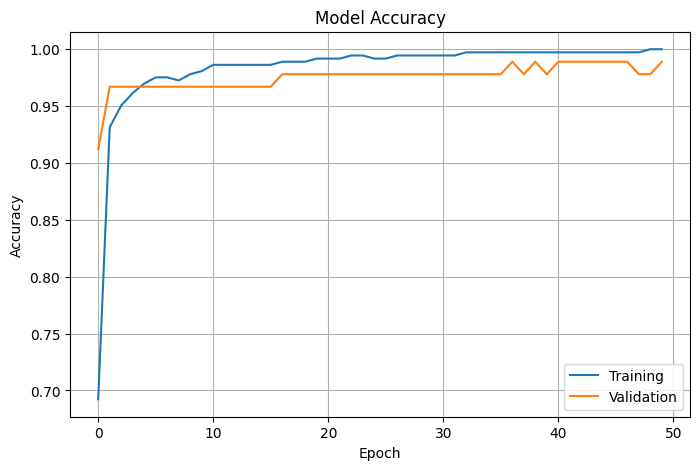

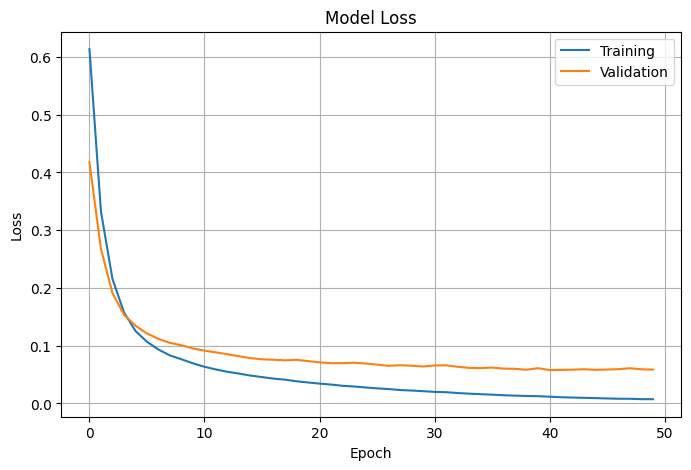

In [ ]:
# EXPT NO: 1
# ANN FOR CLASSIFICATION (BREAST CANCER DATASET)

print("=" * 60)
print("EXPT NO : 1")
print("ARTIFICIAL NEURAL NETWORK FOR CLASSIFICATION")
print("NAME    : ROSHNI ANGEL A")
print("ROLL NO : 24BAD101")
print("=" * 60)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Upload the dataset
uploaded = files.upload()

# Load the dataset
df = pd.read_csv("data.csv") # Corrected filename from 'data(1).csv' to 'data.csv'

# Remove unnecessary columns
if "id" in df.columns:
    df.drop("id", axis=1, inplace=True)

if "Unnamed: 32" in df.columns:
    df.drop("Unnamed: 32", axis=1, inplace=True)

# Convert categorical values into numerical values
df["diagnosis"] = df["diagnosis"].map({
    "M": 0,
    "B": 1
})

# Separate features and target variable
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build the ANN model
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(30,))) # Note: Input shape should be derived from X_train.shape[1] if feature count can change dynamically
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Predict values
predictions = model.predict(X_test)

y_pred = (predictions > 0.5).astype(int)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# Display results
print("\n")
print("=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nConfusion Matrix")
print(cm)

# Plot accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training", "Validation"])
plt.grid(True)
plt.show()

# Plot loss graph
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training", "Validation"])
plt.grid(True)
plt.show()
